# Codveda Technologies Internship

# Level 3 - Task 3: Natural Language Processing (NLP) - Sentiment Analysis

### Intern Name:

**Ashvini Manohar Jadhav**

### Domain:

**Data Analysis**

### Tools Used:

- Python

- Pandas

- NLTK

- TextBlob

- WordCloud

- Matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

# Objective

The objective of this project is to perform sentiment analysis on textual data using Natural Language Processing (NLP).

The project includes:

- Loading the dataset

- Text preprocessing

- Removing stopwords

- Predicting sentiment using TextBlob

- Visualizing sentiment distribution

- Generating a Word Cloud

In [7]:
df = pd.read_csv("Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


# Dataset Information

Dataset Used:
    
- Sentiment dataset.csv

Important Columns:
    
- Text
    
- Sentiment

The dataset contains social media posts and their associated sentiment labels.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 225.0 KB


In [9]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')

In [10]:
df = df[["Text", "Sentiment"]]
df.head()

,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


In [11]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Text Preprocessing

The following preprocessing steps were performed:

- Converted text to lowercase

- Removed URLs

- Removed punctuation

- Tokenized the text

- Removed stopwords

In [12]:
import re

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Text"] = df["Text"].apply(clean_text)

df.head()

,Text,Sentiment,Clean_Text
0,Enjoying a beautiful day at the park! ...,Positive,enjoying beautiful day park
1,Traffic was terrible this morning. ...,Negative,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,Positive,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,Neutral,trying new recipe dinner tonight


# Sentiment Analysis

TextBlob was used to determine the polarity of each text.

Predicted sentiments were classified as:

- Positive

- Negative

- Neutral

In [14]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Clean_Text"].apply(get_sentiment)

df[["Text", "Sentiment", "Predicted_Sentiment"]].head()

,Text,Sentiment,Predicted_Sentiment
0,Enjoying a beautiful day at the park! ...,Positive,Positive
1,Traffic was terrible this morning. ...,Negative,Negative
2,Just finished an amazing workout! 💪 ...,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,Positive


In [15]:
df["Predicted_Sentiment"].value_counts()

Predicted_Sentiment
Neutral     332
Positive    281
Negative    119
Name: count, dtype: int64

# Data Visualization

The sentiment distribution was visualized using:

- Bar Chart

- Word Cloud

These visualizations help understand the frequency of sentiments and commonly used words.

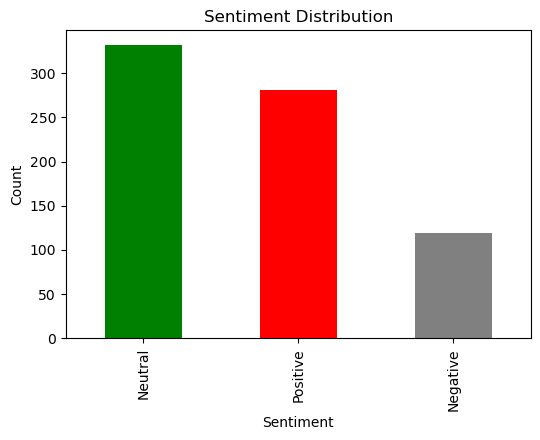

In [16]:
plt.figure(figsize=(6,4))

df["Predicted_Sentiment"].value_counts().plot(
    kind="bar",
    color=["green", "red", "gray"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

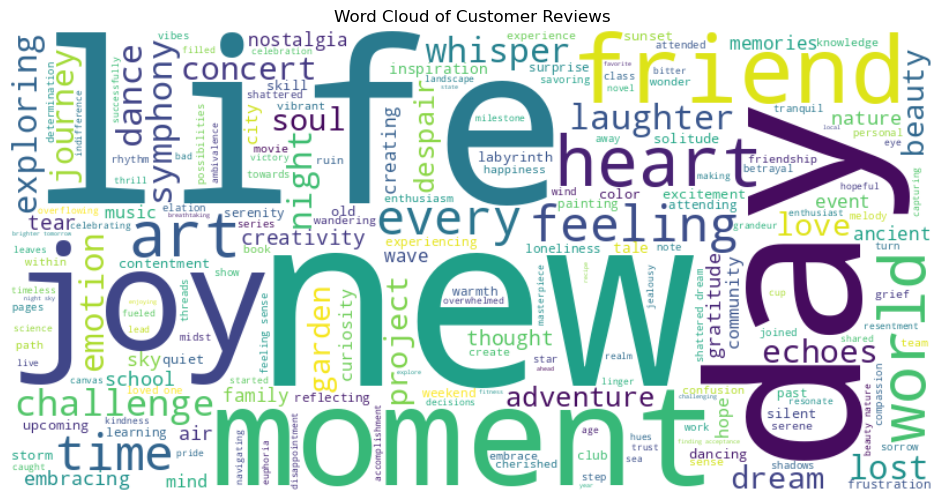

In [17]:
text = " ".join(df["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")
plt.show()

In [19]:
df.to_csv("sentiment_analysis_results.csv", index=False)

# Conclusion

Successfully performed sentiment analysis using Natural Language Processing techniques.

Key achievements:

- Loaded and explored the dataset
    
- Cleaned and preprocessed textual data
    
- Removed stopwords
    
- Predicted sentiment using TextBlob
    
- Visualized sentiment distribution
    
- Generated a Word Cloud

This project demonstrates how NLP techniques can be applied to analyze customer opinions and social media text.